**DDQN comparison**

In [1]:
import heapq
import math
import random
import time
from collections import deque
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


device(type='cpu')

In [2]:
# Hyperparameters are intentionally close to sensorfusion_uav_navigation.ipynb.
# This notebook changes the active sensor set to compare dual-sensor fusion pairs against full fusion.
@dataclass
class Config:
    grid_size: int = 30
    start: tuple = (5, 1)
    target: tuple = (14, 29)
    max_steps: int = 160
    episodes: int = 1000
    gamma: float = 0.90
    lr: float = 0.0025
    batch_size: int = 64
    memory_size: int = 20_000
    target_update: int = 10
    soft_tau: float = 0.02
    eps_start: float = 0.90
    eps_end: float = 0.02
    eps_decay: float = 450.0
    safe_radius: float = 0.60
    target_reward: float = 500.0
    collision_penalty: float = -300.0
    boundary_penalty: float = -300.0
    distance_scale: float = -0.02
    progress_scale: float = 3.0
    step_penalty: float = -0.10
    grad_clip: float = 10.0

    # Energy based reward for agent.
    initial_energy: float = 100.0
    base_energy_cost: float = 0.70
    diagonal_energy_cost: float = 0.30
    corner_energy_cost: float = 0.45
    obstacle_risk_energy_cost: float = 0.25
    camera_warning_energy_cost: float = 0.35
    goal_energy_bonus: float = 25.0
    depleted_energy_penalty: float = -250.0
    energy_reward_scale: float = 0.60


cfg = Config()
CSV_PATH = Path("dual_sensor_comparison_metrics_DDQN.csv")
EPISODE_REWARD_CSV_PATH = Path("dual_sensor_episode_rewards_DDQN.csv")
PLOT_PATH = Path("dual_sensor_paths_DDQN.png")
REWARD_PLOT_PATH = Path("dual_sensor_reward_curves_DDQN.png")
BAR_PATH = Path("dual_sensor_metric_bars_DDQN.png")
CHECKPOINT_DIR = Path("dual_sensor_rl_checkpoints_DDQN")
CHECKPOINT_DIR.mkdir(exist_ok=True)
cfg


Config(grid_size=30, start=(5, 1), target=(14, 29), max_steps=160, episodes=1000, gamma=0.9, lr=0.0025, batch_size=64, memory_size=20000, target_update=10, soft_tau=0.02, eps_start=0.9, eps_end=0.02, eps_decay=450.0, safe_radius=0.6, target_reward=500.0, collision_penalty=-300.0, boundary_penalty=-300.0, distance_scale=-0.02, progress_scale=3.0, step_penalty=-0.1, grad_clip=10.0, initial_energy=100.0, base_energy_cost=0.7, diagonal_energy_cost=0.3, corner_energy_cost=0.45, obstacle_risk_energy_cost=0.25, camera_warning_energy_cost=0.35, goal_energy_bonus=25.0, depleted_energy_penalty=-250.0, energy_reward_scale=0.6)

In [3]:
# Obstacle for the 2D grid
def add_rect(cells, x0, x1, y0, y1):
    for x in range(x0, x1 + 1):
        for y in range(y0, y1 + 1):
            cells.add((x, y))


def build_obstacle_map():
    cells = set()
    add_rect(cells, 6, 8, 27, 29)
    add_rect(cells, 6, 11, 23, 24)
    add_rect(cells, 6, 8, 20, 22)
    add_rect(cells, 0, 6, 16, 17)
    add_rect(cells, 13, 16, 23, 25)
    add_rect(cells, 11, 15, 15, 17)
    add_rect(cells, 10, 12, 6, 8)
    add_rect(cells, 15, 17, 2, 7)
    add_rect(cells, 19, 26, 24, 29)
    add_rect(cells, 20, 24, 8, 9)
    add_rect(cells, 24, 29, 12, 14)
    for i in range(7):
        cells.add((18 + i, 21 - i))
        cells.add((24 + i, 15 + i))
    cells.discard(cfg.start)
    cells.discard(cfg.target)
    return cells


OBSTACLES = build_obstacle_map()
len(OBSTACLES)


187

In [4]:
class SensorFusionUAVGridEnv:
    ACTIONS = np.array([
        [0, 1], [0, -1], [-1, 0], [1, 0],
        [1, 1], [1, -1], [-1, 1], [-1, -1],
    ], dtype=np.float32)
    ACTION_NAMES = ["up", "down", "left", "right", "upper_right",
                    "lower_right", "upper_left", "lower_left"]  # Action space for the agent
    # LiDAR detection direction is up, down, left, right
    LIDAR_DIRECTIONS = np.array(
        [[0, 1], [0, -1], [-1, 0], [1, 0]], dtype=np.int32)

    def __init__(self, config, obstacles):
        self.cfg = config
        self.obstacle_cells = set(obstacles)
        self.obstacles = np.array(sorted(obstacles), dtype=np.float32)
        self.start_pos = np.array(config.start, dtype=np.float32)
        self.target_pos = np.array(config.target, dtype=np.float32)
        self.action_size = len(self.ACTIONS)

        # Environment state vector has 4 parts
        # 5 for base state features [x, y, dist from target, dist from obstacle, normalized remaining energy]

        # 12 LiDAR readings
        # LiDAR has 4 directions for readings [up, down, left, right]
        # And we consider that upto 3 blocks it can sense obstacle presence
        # So 4 directions x 3 grid cells each = 12

        # self.action_size = 8 directions action for agent

        # 4 for IMU styled features
        # IMU helps drone to stabilize and effectively navigate
        # here 4 IMU features are [last motion dx, last motion dy, straight motion indicator, corner motion indicator]
        self.state_size = 5 + 12 + self.action_size + 4
        self.reset()  # Places UAV at start position with resettign energy and history of navigation

    def reset(self):
        self.pos = self.start_pos.copy()
        self.steps = 0
        self.done = False
        self.energy = float(self.cfg.initial_energy)
        self.last_action = None
        self.last_motion = np.zeros(2, dtype=np.float32)
        self.last_motion_kind = "start"
        self.path = [tuple(map(int, self.pos))]
        self.energy_history = [self.energy]
        return self._state()

    # Bounding condition with the boundary
    def _in_bounds(self, cell):
        return 0 <= cell[0] <= self.cfg.grid_size and 0 <= cell[1] <= self.cfg.grid_size

    # Blocking condition with blocks (obstacles)
    def _is_blocked_cell(self, cell):
        cell = tuple(map(int, cell))
        return (not self._in_bounds(cell)) or cell in self.obstacle_cells

    # For calculation of target distance
    def _target_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        return float(np.linalg.norm(p - self.target_pos))

    # For calculation of obstacle distance
    def _obstacle_distance(self, pos=None):
        p = self.pos if pos is None else np.array(pos, dtype=np.float32)
        if len(self.obstacles) == 0:
            return math.sqrt(2) * self.cfg.grid_size
        return float(np.min(np.linalg.norm(self.obstacles - p, axis=1)))

    # For LiDAR reading
    def _lidar_scan(self):
        readings = []
        current = tuple(map(int, self.pos))
        for direction in self.LIDAR_DIRECTIONS:
            for distance in range(1, 4):
                cell = (current[0] + int(direction[0]) * distance,
                        current[1] + int(direction[1]) * distance)
                readings.append(1.0 if self._is_blocked_cell(cell) else 0.0)
        return np.array(readings, dtype=np.float32)

    # Camera's reading for detecting obstacle and efficient navigation
    def _camera_flags(self):
        flags = []
        current = tuple(map(int, self.pos))
        for action in self.ACTIONS.astype(int):
            dx, dy = int(action[0]), int(action[1])
            proposed = (current[0] + dx, current[1] + dy)
            blocked = self._is_blocked_cell(proposed)
            if dx != 0 and dy != 0:
                blocked = blocked or self._is_blocked_cell(
                    (current[0] + dx, current[1])) or self._is_blocked_cell((current[0], current[1] + dy))
            flags.append(1.0 if blocked else 0.0)
        return np.array(flags, dtype=np.float32)

    # For IMU reading
    def _imu_features(self):
        dx, dy = self.last_motion
        straight = 1.0 if self.last_motion_kind == "straight" else 0.0
        corner = 1.0 if self.last_motion_kind == "corner" else 0.0
        return np.array([dx, dy, straight, corner], dtype=np.float32)

    # Calculating current stage of the UAV at present condition
    def _state(self):
        max_dist = math.sqrt(2) * self.cfg.grid_size
        od = min(self._obstacle_distance(), max_dist)
        base = np.array([
            self.pos[0] / self.cfg.grid_size,
            self.pos[1] / self.cfg.grid_size,
            self._target_distance() / max_dist,
            od / max_dist,
            self.energy / self.cfg.initial_energy,
        ], dtype=np.float32)
        return np.concatenate([base, self._lidar_scan(), self._camera_flags(), self._imu_features()]).astype(np.float32)

    # This functio controlling motion of drone
    def _motion_kind(self, action):
        if self.last_action is None:
            return "straight"
        previous = self.ACTIONS[self.last_action]
        current = self.ACTIONS[action]
        return "straight" if np.array_equal(previous, current) else "corner"

    # Energy cost for UAV navigation
    # It associated base energy cost, diagonal energy cost, corner energy cost, obstacle risk energy cost, camera warning energy cost
    def _energy_cost(self, action, camera_blocked):
        move = self.ACTIONS[action]
        cost = self.cfg.base_energy_cost
        if abs(move[0]) + abs(move[1]) == 2:
            cost += self.cfg.diagonal_energy_cost
        if self._motion_kind(action) == "corner":
            cost += self.cfg.corner_energy_cost
        nearby_obstacles = self._lidar_scan().reshape(4, 3)[:, 0].sum()
        cost += self.cfg.obstacle_risk_energy_cost * nearby_obstacles
        if camera_blocked:
            cost += self.cfg.camera_warning_energy_cost
        return float(cost)

    # step function computes
    # new position, collision / out-of-bounds / reached target
    # energy cost from motion type, nearby obstalces and camera warning
    # Reward combining progress, distance, energy changes and penalties
    # It also looked at condition when goal reached, collision, boundary, energy depletion and max steps
    def step(self, action):
        if self.done:
            return self._state(), 0.0, True, {}

        action = int(action)
        previous_td = self._target_distance()
        previous_energy = self.energy
        proposed = self.pos + self.ACTIONS[action]
        camera_flags = self._camera_flags()
        camera_blocked = bool(camera_flags[action] > 0.5)
        energy_cost = self._energy_cost(action, camera_blocked)
        motion_kind = self._motion_kind(action)
        self.steps += 1

        out = proposed[0] < 0 or proposed[0] > self.cfg.grid_size or proposed[1] < 0 or proposed[1] > self.cfg.grid_size
        self.pos = proposed
        self.path.append(tuple(map(int, self.pos)))

        td = self._target_distance()
        od = self._obstacle_distance()
        reached = td <= math.sqrt(2) / 2
        collision = tuple(map(int, self.pos)
                          ) in self.obstacle_cells or od < self.cfg.safe_radius

        self.energy = max(0.0, self.energy - energy_cost)
        if reached:
            self.energy = min(self.cfg.initial_energy,
                              self.energy + self.cfg.goal_energy_bonus)
        energy_delta = self.energy - previous_energy
        energy_depleted = self.energy <= 0.0 and not reached

        reward = self.cfg.step_penalty + self.cfg.distance_scale * \
            td + self.cfg.progress_scale * (previous_td - td)
        reward += self.cfg.energy_reward_scale * energy_delta
        if reached:
            reward += self.cfg.target_reward
        if collision:
            reward += self.cfg.collision_penalty
        if out:
            reward += self.cfg.boundary_penalty
        if energy_depleted:
            reward += self.cfg.depleted_energy_penalty

        self.last_action = action
        self.last_motion = self.ACTIONS[action].copy()
        self.last_motion_kind = motion_kind
        self.energy_history.append(self.energy)
        self.done = bool(
            reached or collision or out or energy_depleted or self.steps >= self.cfg.max_steps)
        info = {
            "target_distance": td,
            "obstacle_distance": od,
            "reached": reached,
            "collision": collision,
            "out_of_bounds": out,
            "energy": self.energy,
            "energy_cost": energy_cost,
            "energy_depleted": energy_depleted,
            "motion_kind": motion_kind,
            "camera_blocked": camera_blocked,
            "lidar_near_obstacles": int(self._lidar_scan().reshape(4, 3)[:, 0].sum()),
        }
        return self._state(), float(reward), self.done, info


env = SensorFusionUAVGridEnv(cfg, OBSTACLES)
env.reset(), env.state_size, env.action_size


(array([0.16666667, 0.03333334, 0.69322115, 0.16666667, 1.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ], dtype=float32),
 29,
 8)

In [5]:
class DualSensorFusionUAVGridEnv(SensorFusionUAVGridEnv):
    VALID_SENSORS = {"lidar", "camera", "imu"}

    def __init__(self, config, obstacles, active_sensors, mode_name="sensor mode"):
        self.active_sensors = tuple(active_sensors)
        self.mode_name = mode_name
        invalid = set(self.active_sensors) - self.VALID_SENSORS
        if invalid:
            raise ValueError(f"Unknown sensors: {sorted(invalid)}")
        super().__init__(config, obstacles)
        self.state_size = self._state().shape[0]

    def has_sensor(self, name):
        return name in self.active_sensors

    def _state(self):
        max_dist = math.sqrt(2) * self.cfg.grid_size
        base = np.array([
            self.pos[0] / self.cfg.grid_size,
            self.pos[1] / self.cfg.grid_size,
            self._target_distance() / max_dist,
            self.energy / self.cfg.initial_energy,
        ], dtype=np.float32)
        features = [base]
        if self.has_sensor("lidar"):
            features.append(self._lidar_scan())
        if self.has_sensor("camera"):
            features.append(self._camera_flags())
        if self.has_sensor("imu"):
            features.append(self._imu_features())
        return np.concatenate(features).astype(np.float32)

    def _energy_cost(self, action, camera_blocked):
        move = self.ACTIONS[action]
        cost = self.cfg.base_energy_cost
        if abs(move[0]) + abs(move[1]) == 2:
            cost += self.cfg.diagonal_energy_cost
        if self.has_sensor("imu") and self._motion_kind(action) == "corner":
            cost += self.cfg.corner_energy_cost
        if self.has_sensor("lidar"):
            nearby_obstacles = self._lidar_scan().reshape(4, 3)[:, 0].sum()
            cost += self.cfg.obstacle_risk_energy_cost * nearby_obstacles
        if self.has_sensor("camera") and camera_blocked:
            cost += self.cfg.camera_warning_energy_cost
        return float(cost)


SENSOR_MODES = {
    "LiDAR + IMU": ("lidar", "imu"),
    "Camera + IMU": ("camera", "imu"),
    "LiDAR + Camera": ("lidar", "camera"),
    "LiDAR + Camera + IMU": ("lidar", "camera", "imu"),
}

for mode_name, sensors in SENSOR_MODES.items():
    env = DualSensorFusionUAVGridEnv(cfg, OBSTACLES, sensors, mode_name)
    print(f"{mode_name:22s} | state_size={env.state_size:2d} | sensors={sensors}")
    

LiDAR + IMU            | state_size=20 | sensors=('lidar', 'imu')
Camera + IMU           | state_size=16 | sensors=('camera', 'imu')
LiDAR + Camera         | state_size=24 | sensors=('lidar', 'camera')
LiDAR + Camera + IMU   | state_size=28 | sensors=('lidar', 'camera', 'imu')


In [6]:
# Deep Q Network
# We're utilizizng 128, 156, 128 structure with ReLU() activation
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, action_size),
        )

    def forward(self, x):
        return self.net(x)

# Dueling Q Network


class DuelingQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
        )
        self.value = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))
        self.advantage = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, action_size))

    def forward(self, x):
        z = self.feature(x)
        value = self.value(z)
        advantage = self.advantage(z)
        return value + advantage - advantage.mean(dim=1, keepdim=True)

# It stores state, action, reward, next_state, done (if the exploration is completed or not) transitions


class ReplayBuffer:
    def __init__(self, capacity):
        self.data = deque(maxlen=capacity)

    def __len__(self):
        return len(self.data)

    def push(self, state, action, reward, next_state, done):
        self.data.append((state, action, reward, next_state, done))

    # It returns the tensor for training RL agent
    def sample(self, batch_size):
        batch = random.sample(self.data, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE),
            torch.tensor(actions, dtype=torch.long,
                         device=DEVICE).unsqueeze(1),
            torch.tensor(rewards, dtype=torch.float32,
                         device=DEVICE).unsqueeze(1),
            torch.tensor(np.array(next_states),
                         dtype=torch.float32, device=DEVICE),
            torch.tensor(dones, dtype=torch.float32,
                         device=DEVICE).unsqueeze(1),
        )
    

In [7]:
# Our RL agent will be trained on 4 speific algorithm
# DQN, Double DQN, Dueling DQN, IDDQN
class RLAgent:
    def __init__(self, state_size, action_size, config, algorithm):
        self.cfg = config
        self.algorithm = algorithm
        self.action_size = action_size
        use_dueling = algorithm in {"Dueling DQN", "IDDQN"}
        net_cls = DuelingQNetwork if use_dueling else QNetwork
        self.current_net = net_cls(state_size, action_size).to(DEVICE)
        self.target_net = net_cls(state_size, action_size).to(DEVICE)
        self.target_net.load_state_dict(self.current_net.state_dict())
        self.target_net.eval()
        self.memory = ReplayBuffer(config.memory_size)
        self.optimizer = optim.Adam(
            self.current_net.parameters(), lr=config.lr)
        self.loss_fn = nn.MSELoss()

    # Specific exploration strategy for IDDQN algorithm.
    # Taken from paper Path Planning of Autonomous Mobile Robot in Comprehensive Unknown Environment Using Deep Reinforcement Learning
    def epsilon(self, episode):
        if self.algorithm == "IDDQN":
            return self.cfg.eps_end + (self.cfg.eps_start - self.cfg.eps_end) / (1.0 + math.exp(episode / self.cfg.eps_decay))
        decay = max(0.05, self.cfg.eps_start * (0.995 ** episode))
        return max(self.cfg.eps_end, decay)

    def act(self, state, episode=10_000, greedy=False):
        eps = 0.0 if greedy else self.epsilon(episode)
        if random.random() < eps:
            return random.randrange(self.action_size)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32,
                             device=DEVICE).unsqueeze(0)
            return int(self.current_net(s).argmax(dim=1).item())

    # Learns from replay buffer and updates current network
    def learn(self):
        if len(self.memory) < self.cfg.batch_size:
            return None
        states, actions, rewards, next_states, dones = self.memory.sample(
            self.cfg.batch_size)
        q_values = self.current_net(states).gather(1, actions)
        with torch.no_grad():
            if self.algorithm in {"Double DQN", "IDDQN"}:
                next_actions = self.current_net(
                    next_states).argmax(dim=1, keepdim=True)
                next_q = self.target_net(next_states).gather(1, next_actions)
            else:
                next_q = self.target_net(next_states).max(
                    dim=1, keepdim=True).values
            target = rewards + self.cfg.gamma * next_q * (1.0 - dones)
        loss = self.loss_fn(q_values, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            self.current_net.parameters(), self.cfg.grad_clip)
        self.optimizer.step()
        return float(loss.item())

    # Hard copy or soft target updates the target network
    def update_target(self, soft=False):
        if soft:
            tau = self.cfg.soft_tau
            for target_param, current_param in zip(self.target_net.parameters(), self.current_net.parameters()):
                target_param.data.copy_(
                    tau * current_param.data + (1.0 - tau) * target_param.data)
        else:
            self.target_net.load_state_dict(self.current_net.state_dict())
            

In [8]:

# A special thing
# A* expert warm start, start_path() computes an A* reference path from start to target through the grid
def astar_path(start=cfg.start, target=cfg.target):
    obstacles = set(OBSTACLES)
    actions = [tuple(map(int, a)) for a in DualSensorFusionUAVGridEnv.ACTIONS]

    def h(cell):
        return math.hypot(cell[0] - target[0], cell[1] - target[1])

    queue = [(h(start), 0.0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0.0}
    while queue:
        _, cost, current = heapq.heappop(queue)
        if current == target:
            break
        for dx, dy in actions:
            nxt = (current[0] + dx, current[1] + dy)
            if nxt[0] < 0 or nxt[0] > cfg.grid_size or nxt[1] < 0 or nxt[1] > cfg.grid_size or nxt in obstacles:
                continue
            new_cost = cost + math.hypot(dx, dy)
            if new_cost < cost_so_far.get(nxt, float("inf")):
                cost_so_far[nxt] = new_cost
                came_from[nxt] = current
                heapq.heappush(queue, (new_cost + h(nxt), new_cost, nxt))
    if target not in came_from:
        return []
    path = []
    cell = target
    while cell is not None:
        path.append(cell)
        cell = came_from[cell]
    return path[::-1]

# Simulates the finding path in the 2D grid environment


def expert_transitions(env, path):
    action_lookup = {tuple(map(int, action)): idx for idx,
                     action in enumerate(env.ACTIONS)}
    transitions = []
    state = env.reset()
    for current, nxt in zip(path[:-1], path[1:]):
        action = action_lookup[(nxt[0] - current[0], nxt[1] - current[1])]
        next_state, reward, done, _ = env.step(action)
        transitions.append((state, action, reward, next_state, done))
        state = next_state
        if done:
            break
    return transitions

# Fill agent memory with expert transition


def prefill_replay(env, agent, path, repeats=50):
    transitions = expert_transitions(env, path)
    for _ in range(repeats):
        for transition in transitions:
            agent.memory.push(*transition)

# Trains the network to imitate the expert behaviour and path via supervised cross-entropy


def behavior_clone(env, agent, path, epochs=200):
    transitions = expert_transitions(env, path)
    if not transitions:
        return None
    states = torch.tensor(
        np.array([t[0] for t in transitions]), dtype=torch.float32, device=DEVICE)
    actions = torch.tensor([t[1] for t in transitions],
                           dtype=torch.long, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        logits = agent.current_net(states)
        loss = loss_fn(logits, actions)
        agent.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(
            agent.current_net.parameters(), agent.cfg.grad_clip)
        agent.optimizer.step()
    agent.target_net.load_state_dict(agent.current_net.state_dict())
    return float(loss.item())


expert_path = astar_path()
len(expert_path) - 1


28

In [9]:
# Function for training an agent in exploration and exploitation
def train_agent(env, agent, episodes=None, verbose_every=100):
    episodes = episodes or env.cfg.episodes
    history = {"reward": [], "steps": [],
               "success": [], "loss": [], "final_energy": []}
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0.0
        losses = []
        final_info = {}
        for _ in range(env.cfg.max_steps):
            action = agent.act(state, episode)
            next_state, reward, done, info = env.step(action)
            agent.memory.push(state, action, reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                losses.append(loss)
            if agent.algorithm == "IDDQN":
                agent.update_target(soft=True)
            state = next_state
            total_reward += reward
            final_info = info
            if done:
                break
        if agent.algorithm != "IDDQN" and episode % env.cfg.target_update == 0:
            agent.update_target(soft=False)
        history["reward"].append(total_reward)
        history["steps"].append(env.steps)
        history["success"].append(bool(final_info.get("reached", False)))
        history["loss"].append(float(np.mean(losses)) if losses else np.nan)
        history["final_energy"].append(
            float(final_info.get("energy", env.energy)))
        if verbose_every and (episode + 1) % verbose_every == 0:
            recent_success = np.mean(history["success"][-verbose_every:])
            print(f"{agent.algorithm:12s} | episode {episode + 1:4d}/{episodes} | reward {total_reward:8.2f} | energy {env.energy:6.2f} | recent success {recent_success:.2f}")
    return history


# Evaluates the trained policy greedily and returns path, reward, info time.
def greedy_rollout(env, agent):
    start_time = time.perf_counter()
    state = env.reset()
    total_reward = 0.0
    final_info = {}
    for _ in range(env.cfg.max_steps):
        action = agent.act(state, greedy=True)
        state, reward, done, info = env.step(action)
        total_reward += reward
        final_info = info
        if done:
            break
    elapsed_ms = (time.perf_counter() - start_time) * 1000
    return list(env.path), list(env.energy_history), total_reward, final_info, elapsed_ms


In [10]:
def path_length(path):
    return float(sum(math.hypot(b[0] - a[0], b[1] - a[1]) for a, b in zip(path[:-1], path[1:])))


def count_corners(path):
    if len(path) < 3:
        return 0
    corners = 0
    prev = (path[1][0] - path[0][0], path[1][1] - path[0][1])
    for a, b in zip(path[1:-1], path[2:]):
        step = (b[0] - a[0], b[1] - a[1])
        if step != prev:
            corners += 1
        prev = step
    return corners


# Add DQN, Double DQN, or Dueling DQN for a larger fusion + algorithm study.
ALGORITHMS = ["Double DQN"]
RUN_TRAINING = True
USE_EXPERT_WARMSTART = True
histories = {}
agents = {}
rollouts = {}
rows = []

for mode_name, sensors in SENSOR_MODES.items():
    env = DualSensorFusionUAVGridEnv(cfg, OBSTACLES, sensors, mode_name)
    for algorithm in ALGORITHMS:
        print(f"Training {algorithm} with {mode_name}...")
        agent = RLAgent(env.state_size, env.action_size, cfg, algorithm)
        if USE_EXPERT_WARMSTART and expert_path:
            prefill_replay(env, agent, expert_path, repeats=50)
            behavior_clone(env, agent, expert_path,
                           epochs=120 if algorithm == "IDDQN" else 60)
        checkpoint_name = f"{mode_name.lower().replace(' + ', '_').replace(' ', '_')}_{algorithm.lower().replace(' ', '_')}.pth"
        checkpoint_path = CHECKPOINT_DIR / checkpoint_name
        key = f"{mode_name} | {algorithm}"
        if RUN_TRAINING:
            histories[key] = train_agent(env, agent, verbose_every=100)
            torch.save(agent.current_net.state_dict(), checkpoint_path)
        elif checkpoint_path.exists():
            agent.current_net.load_state_dict(
                torch.load(checkpoint_path, map_location=DEVICE))
            agent.target_net.load_state_dict(agent.current_net.state_dict())
            histories[key] = {"reward": [], "steps": [],
                              "success": [], "loss": [], "final_energy": []}
        else:
            raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

        path, energy_trace, total_reward, info, elapsed_ms = greedy_rollout(
            env, agent)
        agents[key] = agent
        rollouts[key] = {"sensor_mode": mode_name, "algorithm": algorithm, "path": path,
                         "energy": energy_trace, "reward": total_reward, "info": info, "elapsed_ms": elapsed_ms}
        rows.append({
            "sensor_mode": mode_name,
            "active_sensors": "+".join(sensors),
            "algorithm": algorithm,
            "state_size": env.state_size,
            "reward": total_reward,
            "steps": len(path) - 1,
            "path_length": path_length(path),
            "corners": count_corners(path),
            "success": bool(info.get("reached", False)),
            "final_energy": float(info.get("energy", env.energy)),
            "energy_used": float(cfg.initial_energy - info.get("energy", env.energy)),
            "inference_time_ms": elapsed_ms,
            "collision": bool(info.get("collision", False)),
            "out_of_bounds": bool(info.get("out_of_bounds", False)),
            "energy_depleted": bool(info.get("energy_depleted", False)),
        })

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv(CSV_PATH, index=False)

reward_rows = []
for key, history in histories.items():
    mode_name, algorithm = key.split(" | ", 1)
    for episode, reward in enumerate(history["reward"], start=1):
        reward_rows.append(
            {"sensor_mode": mode_name, "algorithm": algorithm, "episode": episode, "reward": reward})
pd.DataFrame(reward_rows).to_csv(EPISODE_REWARD_CSV_PATH, index=False)
comparison_df


Training Double DQN with LiDAR + IMU...
Double DQN   | episode  100/1000 | reward  -320.01 | energy  47.20 | recent success 0.00
Double DQN   | episode  200/1000 | reward  -309.17 | energy  47.50 | recent success 0.01
Double DQN   | episode  300/1000 | reward  -318.09 | energy  64.30 | recent success 0.18
Double DQN   | episode  400/1000 | reward   569.40 | energy  88.10 | recent success 0.37
Double DQN   | episode  500/1000 | reward   565.97 | energy  84.95 | recent success 0.64
Double DQN   | episode  600/1000 | reward   564.76 | energy  85.25 | recent success 0.78
Double DQN   | episode  700/1000 | reward   572.01 | energy  91.00 | recent success 0.88
Double DQN   | episode  800/1000 | reward   572.71 | energy  92.75 | recent success 0.90
Double DQN   | episode  900/1000 | reward   567.62 | energy  87.65 | recent success 0.83
Double DQN   | episode 1000/1000 | reward   571.64 | energy  91.25 | recent success 0.83
Training Double DQN with Camera + IMU...
Double DQN   | episode  100/1

,sensor_mode,active_sensors,algorithm,state_size,reward,steps,path_length,corners,success,final_energy,energy_used,inference_time_ms,collision,out_of_bounds,energy_depleted
0,LiDAR + IMU,lidar+imu,Double DQN,20,572.981676,28,35.041631,13,True,92.70,7.30,9.9389,False,False,False
1,Camera + IMU,camera+imu,Double DQN,16,-255.540681,24,25.656854,5,False,79.05,20.95,5.9366,True,False,False
2,LiDAR + Camera,lidar+camera,Double DQN,24,576.606789,28,33.384776,11,True,98.40,1.60,7.5991,False,False,False
3,LiDAR + Camera + IMU,lidar+camera+imu,Double DQN,28,573.688551,28,33.384776,11,True,93.85,6.15,8.6467,False,False,False


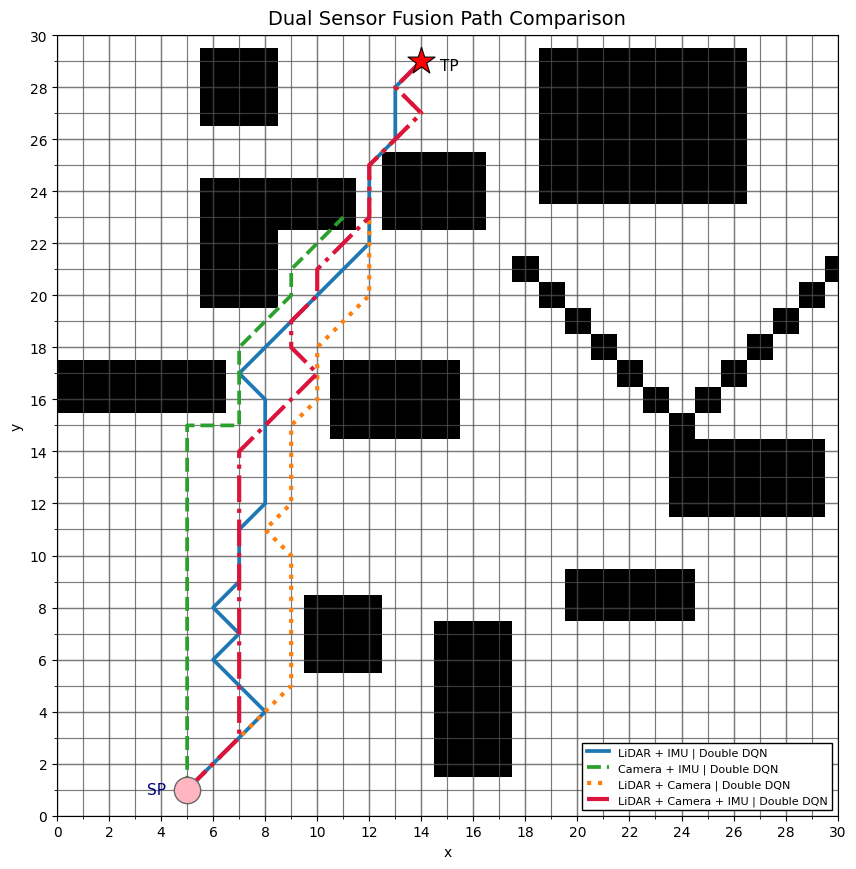

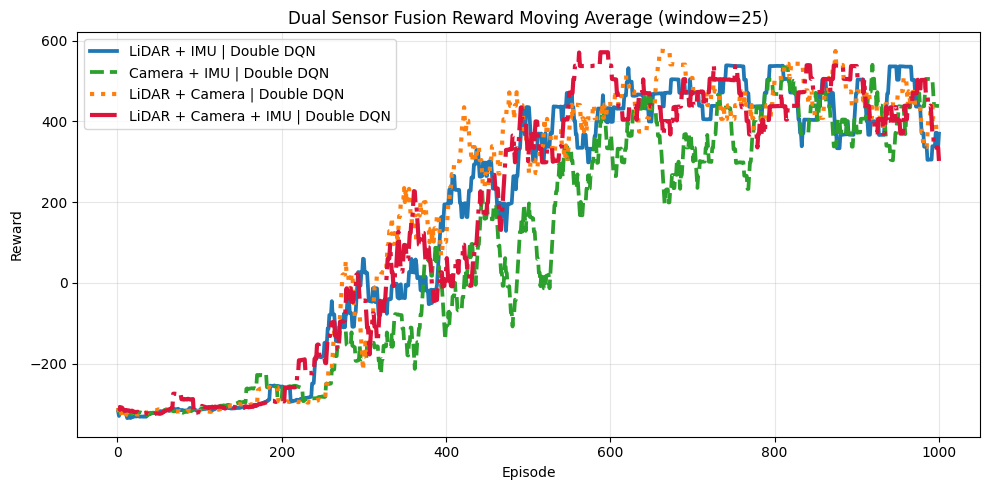

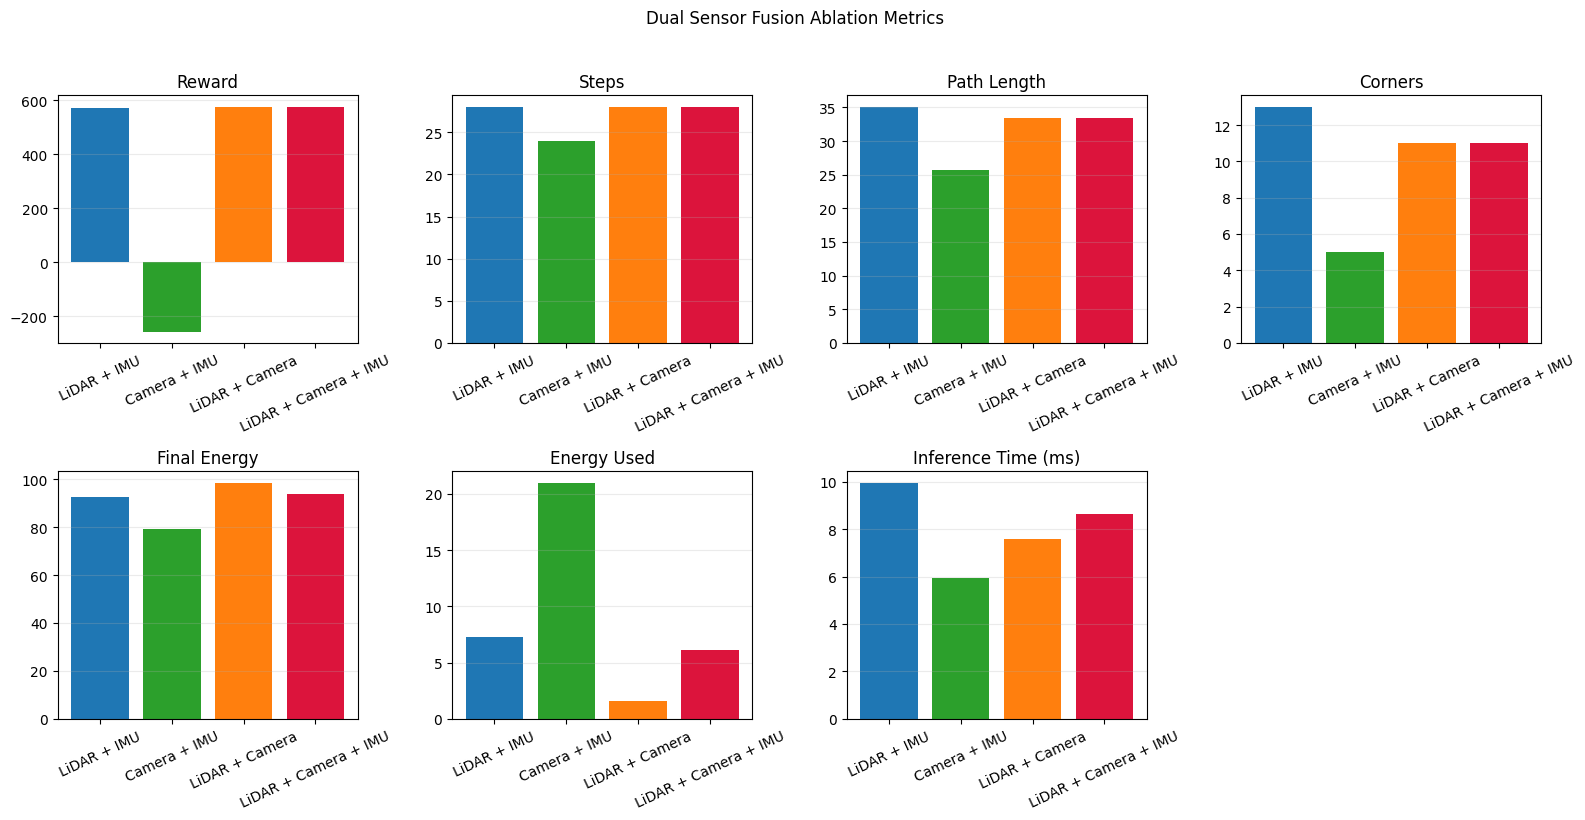

In [11]:
STYLE = {
    "LiDAR + IMU": {"color": "tab:blue", "linestyle": "-", "linewidth": 2.7},
    "Camera + IMU": {"color": "tab:green", "linestyle": "--", "linewidth": 2.7},
    "LiDAR + Camera": {"color": "tab:orange", "linestyle": ":", "linewidth": 3.0},
    "LiDAR + Camera + IMU": {"color": "crimson", "linestyle": "-.", "linewidth": 3.0},
}


def plot_paths(rollouts, save_path=PLOT_PATH):
    fig, ax = plt.subplots(figsize=(8.8, 8.8))
    obstacle_grid = np.zeros(
        (cfg.grid_size + 1, cfg.grid_size + 1), dtype=float)
    for x, y in OBSTACLES:
        if 0 <= x <= cfg.grid_size and 0 <= y <= cfg.grid_size:
            obstacle_grid[y, x] = 1.0
    masked_obstacles = np.ma.masked_where(obstacle_grid == 0, obstacle_grid)
    ax.imshow(masked_obstacles, cmap=plt.cm.gray_r, origin="lower", extent=(-0.5,
              cfg.grid_size + 0.5, -0.5, cfg.grid_size + 0.5), interpolation="nearest", vmin=0, vmax=1)
    for key, result in rollouts.items():
        path = np.array(result["path"])
        mode_name = result["sensor_mode"]
        ax.plot(path[:, 0], path[:, 1], label=key, **STYLE[mode_name])
    ax.scatter(*cfg.start, c="lightpink", s=360, marker="o",
               edgecolors="dimgray", linewidths=1.0, zorder=5)
    ax.scatter(*cfg.target, c="red", s=420, marker="*",
               edgecolors="black", linewidths=0.8, zorder=6)
    ax.text(cfg.start[0] - 1.55, cfg.start[1] -
            0.15, "SP", color="navy", fontsize=11)
    ax.text(cfg.target[0] + 0.70, cfg.target[1] -
            0.35, "TP", color="black", fontsize=11)
    ax.set_xlim(0, cfg.grid_size)
    ax.set_ylim(0, cfg.grid_size)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks(np.arange(0, cfg.grid_size + 1, 2))
    ax.set_yticks(np.arange(0, cfg.grid_size + 1, 2))
    ax.set_xticks(np.arange(0, cfg.grid_size + 1, 1), minor=True)
    ax.set_yticks(np.arange(0, cfg.grid_size + 1, 1), minor=True)
    ax.grid(which="minor", color="#4f4f4f", linewidth=0.85, alpha=0.75)
    ax.grid(which="major", color="#4f4f4f", linewidth=1.05, alpha=0.75)
    ax.set_title("Dual Sensor Fusion Path Comparison", fontsize=14, pad=8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(loc="lower right", frameon=True, fancybox=False,
              framealpha=1.0, edgecolor="black", fontsize=8)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180)
    return fig, ax


def plot_reward_curves(histories, window=25, save_path=REWARD_PLOT_PATH):
    fig, ax = plt.subplots(figsize=(10, 5))
    for key, history in histories.items():
        rewards = pd.Series(history["reward"], dtype="float64")
        if rewards.empty:
            continue
        mode_name = key.split(" | ", 1)[0]
        smoothed = rewards.rolling(window=window, min_periods=1).mean()
        ax.plot(smoothed.index + 1, smoothed.values,
                label=key, **STYLE[mode_name])
    ax.set_title(f"Dual Sensor Fusion Reward Moving Average (window={window})")
    ax.set_xlabel("Episode")
    ax.set_ylabel("Reward")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=180)
    return fig, ax


def plot_metric_bars(df, save_path=BAR_PATH):
    metrics = [("reward", "Reward"), ("steps", "Steps"), ("path_length", "Path Length"), ("corners", "Corners"),
               ("final_energy", "Final Energy"), ("energy_used", "Energy Used"), ("inference_time_ms", "Inference Time (ms)")]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    labels = df["sensor_mode"] if df["algorithm"].nunique(
    ) == 1 else df["sensor_mode"] + "\n" + df["algorithm"]
    colors = [STYLE[m]["color"] for m in df["sensor_mode"]]
    for ax, (metric, label) in zip(axes, metrics):
        ax.bar(labels, df[metric], color=colors)
        ax.set_title(label)
        ax.tick_params(axis="x", rotation=25)
        ax.grid(axis="y", alpha=0.25)
    axes[-1].axis("off")
    fig.suptitle("Dual Sensor Fusion Ablation Metrics", y=1.02)
    fig.tight_layout()
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    return fig, axes


plot_paths(rollouts)
plot_reward_curves(histories)
plot_metric_bars(comparison_df)
plt.show()

In [12]:
# Reload saved metrics when only plotting/reporting is needed.
comparison_df = pd.read_csv(CSV_PATH)
comparison_df

,sensor_mode,active_sensors,algorithm,state_size,reward,steps,path_length,corners,success,final_energy,energy_used,inference_time_ms,collision,out_of_bounds,energy_depleted
0,LiDAR + IMU,lidar+imu,Double DQN,20,572.981676,28,35.041631,13,True,92.70,7.30,9.9389,False,False,False
1,Camera + IMU,camera+imu,Double DQN,16,-255.540681,24,25.656854,5,False,79.05,20.95,5.9366,True,False,False
2,LiDAR + Camera,lidar+camera,Double DQN,24,576.606789,28,33.384776,11,True,98.40,1.60,7.5991,False,False,False
3,LiDAR + Camera + IMU,lidar+camera+imu,Double DQN,28,573.688551,28,33.384776,11,True,93.85,6.15,8.6467,False,False,False
